In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import pickle
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
# El nombre de la carpeta
dataset_path = '/content/drive/MyDrive/RootKit/PlantVillage'
#dataset_path = '/home/mats/Documentos/RootKit/dataset/PlantVillage'

# Verificar que lo encuentra
if os.path.exists(dataset_path):
    print("Dataset encontrado")
else:
    print("No encontrado")

Dataset encontrado


In [4]:
RANGOS_PLANTAS = {
    'Tomato': {'hoja': ([5, 20, 20], [95, 255, 255]), 'sano': ([25, 25, 25], [95, 255, 255])},
    'Potato': {'hoja': ([0, 10, 10], [90, 255, 255]), 'sano': ([38, 50, 50], [90, 255, 255])},
    'Pepper': {'hoja': ([25, 30, 30], [95, 255, 255]), 'sano': ([35, 50, 50], [95, 255, 255])},
    'default': {'hoja': ([0, 20, 20], [100, 255, 255]), 'sano': ([35, 40, 40], [90, 255, 255])}
}

In [5]:
def procesar_con_clase(ruta_imagen, nombre_clase):
    img = cv2.imread(ruta_imagen)
    if img is None: return None, None

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Buscamos si la palabra clave (ej. 'Tomato') está en el nombre de la clase
    rango = RANGOS_PLANTAS['default'] # Por defecto
    for planta in RANGOS_PLANTAS:
        if planta.lower() in nombre_clase.lower():
            rango = RANGOS_PLANTAS[planta]
            break

    # Aplicar los rangos seleccionados
    lower_leaf, upper_leaf = np.array(rango['hoja'][0]), np.array(rango['hoja'][1])
    lower_green, upper_green = np.array(rango['sano'][0]), np.array(rango['sano'][1])

    mask_leaf = cv2.inRange(hsv, lower_leaf, upper_leaf)
    mask_healthy = cv2.inRange(hsv, lower_green, upper_green)

    # Cálculo de severidad
    area_hoja = np.count_nonzero(mask_leaf)
    if area_hoja == 0: return None, None

    mask_infected = cv2.bitwise_and(mask_leaf, cv2.bitwise_not(mask_healthy))
    severidad = (np.count_nonzero(mask_infected) / area_hoja) * 100

    # Histograma
    hist_hue = cv2.calcHist([hsv], [0], mask_leaf, [16], [0, 180])
    cv2.normalize(hist_hue, hist_hue)

    return hist_hue.flatten(), severidad

Depurando como: Potato


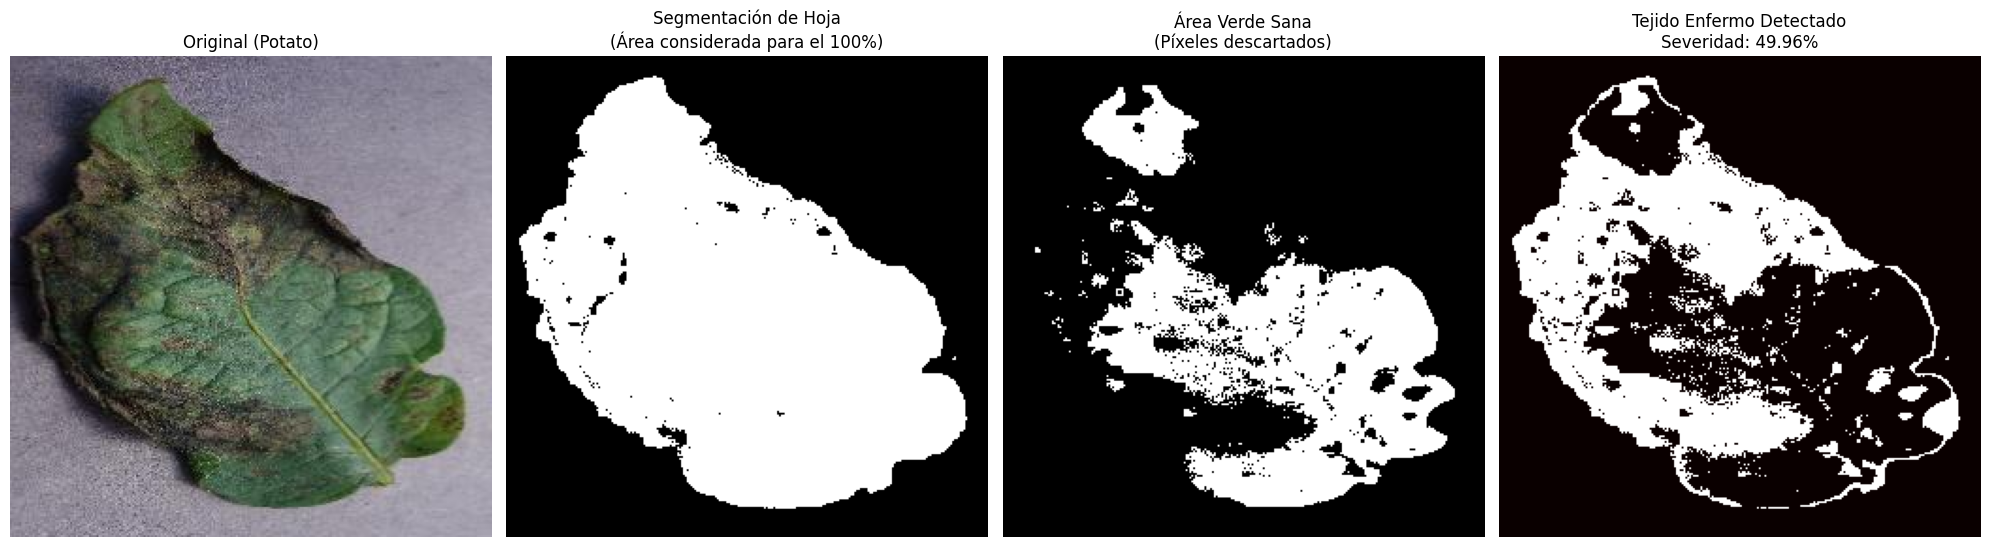

In [17]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def depurar_imagen_con_rangos(ruta_imagen):
    # 1. Cargar imagen
    img = cv2.imread(ruta_imagen)
    if img is None:
        print(f"Error: No se pudo cargar la imagen en {ruta_imagen}")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # 2. Identificar la planta por la ruta (Carpeta)
    # Buscamos 'Tomato', 'Potato' o 'Pepper' en el path
    planta_clave = "default"
    for p in RANGOS_PLANTAS.keys():
        if p.lower() in ruta_imagen.lower():
            planta_clave = p
            break

    rango = RANGOS_PLANTAS[planta_clave]
    print(f"Depurando como: {planta_clave}")

    # 3. Aplicar los rangos específicos del diccionario
    lower_leaf = np.array(rango['hoja'][0])
    upper_leaf = np.array(rango['hoja'][1])
    mask_leaf = cv2.inRange(hsv, lower_leaf, upper_leaf)

    lower_green = np.array(rango['sano'][0])
    upper_green = np.array(rango['sano'][1])
    mask_healthy = cv2.inRange(hsv, lower_green, upper_green)

    # 4. Calcular infección (Lo que es hoja pero NO es verde sano)
    mask_infection = cv2.bitwise_and(mask_leaf, cv2.bitwise_not(mask_healthy))

    # 5. Calcular severidad matemática
    total_hoja = np.count_nonzero(mask_leaf)
    if total_hoja > 0:
        severidad = (np.count_nonzero(mask_infection) / total_hoja) * 100
    else:
        severidad = 0

    # 6. Visualización
    plt.figure(figsize=(20, 6))

    plt.subplot(1, 4, 1)
    plt.imshow(img_rgb)
    plt.title(f"Original ({planta_clave})")
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(mask_leaf, cmap='gray')
    plt.title("Segmentación de Hoja\n(Área considerada para el 100%)")
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(mask_healthy, cmap='gray')
    plt.title("Área Verde Sana\n(Píxeles descartados)")
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(mask_infection, cmap='hot')
    plt.title(f"Tejido Enfermo Detectado\nSeveridad: {severidad:.2f}%")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# --- PRUEBA CON TU IMAGEN DE PAPA ---
# Sustituye con la ruta de la imagen de papa que me mostraste
ruta_img = '/content/drive/MyDrive/RootKit/PlantVillage/Potato___Late_blight/8c894440-a022-41a8-9545-51ff4286d29f___RS_LB 5126.JPG'
depurar_imagen_con_rangos(ruta_img)

In [16]:
ruta_test = '/content/drive/MyDrive/RootKit/PlantVillage/Potato___Late_blight/8c894440-a022-41a8-9545-51ff4286d29f___RS_LB 5126.JPG'
feat, sev = procesar_con_clase(ruta_test, 'Potato___Late_blight')
print(f"Severidad calculada para el entrenamiento: {sev:.2f}%")

Severidad calculada para el entrenamiento: 49.96%


In [10]:
import glob
import os

# 1. Ajusta la ruta a tu carpeta de Drive
#dataset_path = '/content/drive/MyDrive/RootKit/dataset/PlantVillage'

datos_extraidos = []

print("Iniciando extracción de features en Drive...")

# 2. Glob funciona igual, pero añadimos recursividad por si acaso
rutas_train = glob.glob(os.path.join(dataset_path, "**/*.JPG"), recursive=True) + \
              glob.glob(os.path.join(dataset_path, "**/*.jpg"), recursive=True) + \
              glob.glob(os.path.join(dataset_path, "**/*.png"), recursive=True)

for i, ruta in enumerate(rutas_train):
    # FORMA SEGURA: Obtener el nombre de la carpeta contenedora
    # os.path.dirname(ruta) nos da la ruta de la carpeta,
    # y basename nos da el nombre final (ej: "Tomato_Early_blight")
    clase_nombre = os.path.basename(os.path.dirname(ruta))

    # 3. Procesar
    features, sev = procesar_con_clase(ruta, clase_nombre)

    if features is not None:
        fila = list(features) + [sev]
        datos_extraidos.append(fila)

    if i % 500 == 0:
        print(f"Progreso: {i} imágenes procesadas...")

print(f"\n¡Listo! Total de muestras en Drive: {len(datos_extraidos)}")

Iniciando extracción de features en Drive...
Progreso: 0 imágenes procesadas...
Progreso: 500 imágenes procesadas...
Progreso: 1000 imágenes procesadas...
Progreso: 1500 imágenes procesadas...
Progreso: 2000 imágenes procesadas...
Progreso: 2500 imágenes procesadas...
Progreso: 3000 imágenes procesadas...
Progreso: 3500 imágenes procesadas...
Progreso: 4000 imágenes procesadas...
Progreso: 4500 imágenes procesadas...
Progreso: 5000 imágenes procesadas...
Progreso: 5500 imágenes procesadas...
Progreso: 6000 imágenes procesadas...
Progreso: 6500 imágenes procesadas...
Progreso: 7000 imágenes procesadas...
Progreso: 7500 imágenes procesadas...
Progreso: 8000 imágenes procesadas...
Progreso: 8500 imágenes procesadas...
Progreso: 9000 imágenes procesadas...
Progreso: 9500 imágenes procesadas...
Progreso: 10000 imágenes procesadas...
Progreso: 10500 imágenes procesadas...
Progreso: 11000 imágenes procesadas...
Progreso: 11500 imágenes procesadas...
Progreso: 12000 imágenes procesadas...
Prog

In [12]:
# 3. Construir el DataFrame dinámico
# Creamos nombres para las 16 columnas del histograma
columnas = [f'Hue_Bin_{i}' for i in range(16)] + ['Severidad']
df = pd.DataFrame(datos_extraidos, columns=columnas)

In [13]:
# 4. Separar X e y
X = df.drop(columns=['Severidad'])
y = df['Severidad']

In [14]:

# 5. Dividir datos, entrenar y evaluar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

print("\nEntrenando RandomForestRegressor...")
modelo = RandomForestRegressor(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

predicciones = modelo.predict(X_test)
r2 = r2_score(y_test, predicciones)
mae = mean_absolute_error(y_test, predicciones)

print(f"\n--- Resultados Finales ---")
print(f"R2 Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")


Entrenando RandomForestRegressor...

--- Resultados Finales ---
R2 Score: 0.9031
MAE: 3.5843


In [15]:


# 6. Exportar si cumple la meta
if r2 > 0.70:
    ruta_exportacion = '/content/drive/MyDrive/RootKit/models/regresion_severidad.pkl'
    with open(ruta_exportacion, 'wb') as f:
        pickle.dump(modelo, f)
    print(f"\n¡Éxito! Modelo exportado como '{ruta_exportacion}'.")
else:
    print("\nEl R2 es menor a 0.70.")


¡Éxito! Modelo exportado como '/content/drive/MyDrive/RootKit/models/regresion_severidad.pkl'.
